```
https://www.kaggle.com/code/b1aze7/traficlightcontrol-trainyolov8
continue..
```

In [2]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import os

In [4]:
import warnings
warnings.filterwarnings('ignore')

import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from PIL import Image
from ultralytics import YOLO
from IPython.display import Video

In [5]:
sns.set(rc={'axes.facecolor': '#eae8fa'}, style='darkgrid')

In [6]:
model = YOLO('yolov8n.pt')


image 1/1 /Users/jeongjaehun/Github/03_object_detection/dataset/vehicle_detection/vehicle-detection-image-dataset/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.yolov8/train/images/frame_1030_jpg.rf.98527a93c719ca44a6b907071023cb68.jpg: 640x640 5 cars, 53.2ms
Speed: 2.0ms preprocess, 53.2ms inference, 9.1ms postprocess per image at shape (1, 3, 640, 640)


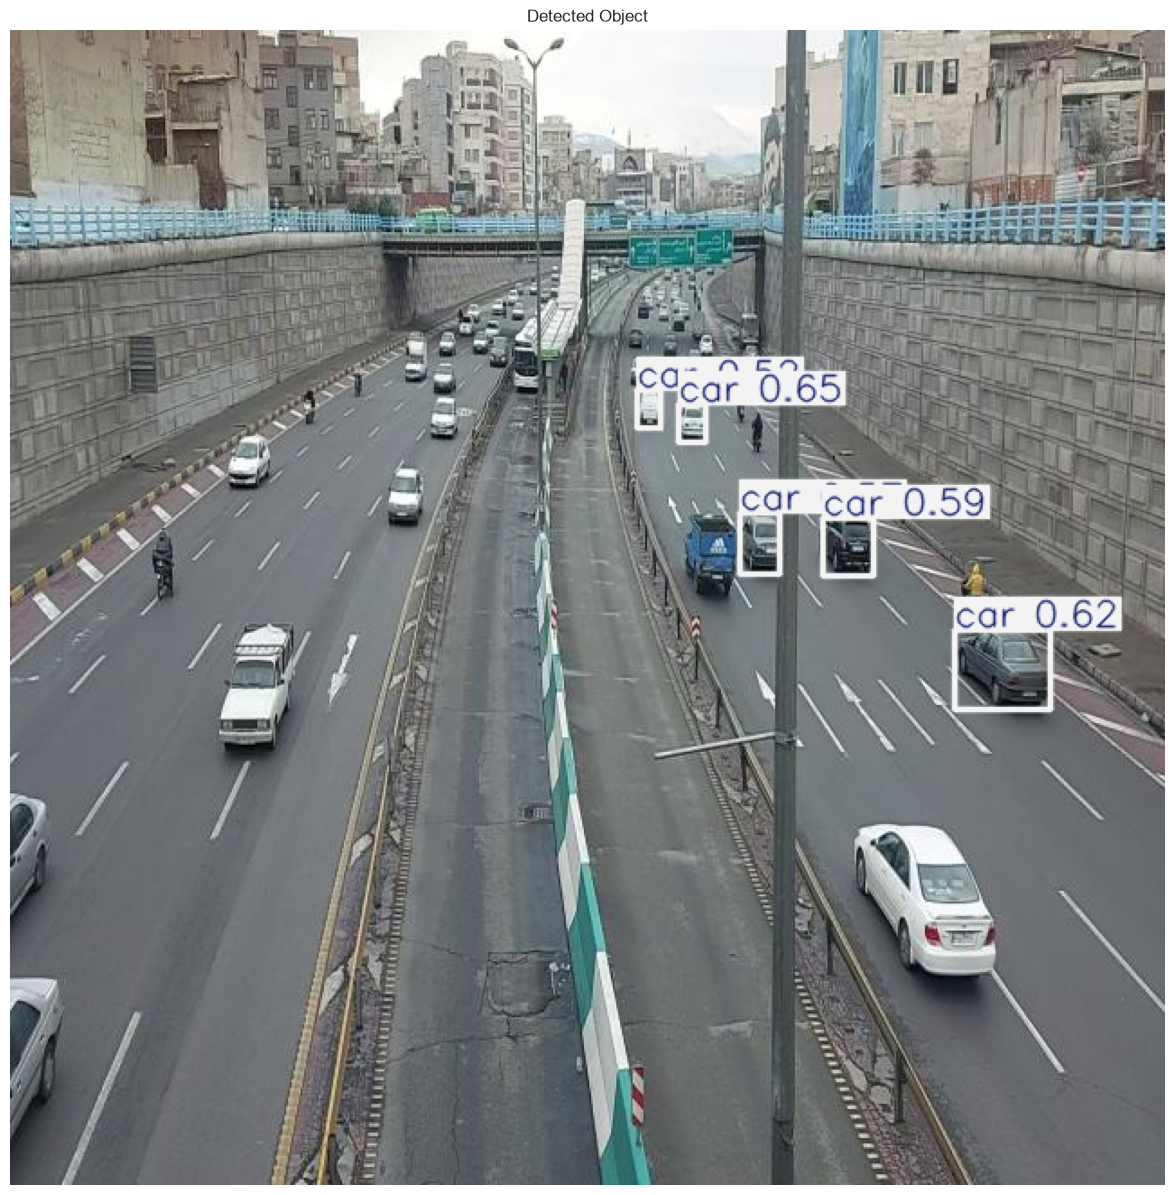

In [7]:
image_path = 'dataset/vehicle_detection/vehicle-detection-image-dataset/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.yolov8/train/images/frame_1030_jpg.rf.98527a93c719ca44a6b907071023cb68.jpg'

results = model.predict(source=image_path, 
                        imgsz=640, 
                        conf=0.5)

sample_image = results[0].plot(line_width=2)

sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 15))
plt.imshow(sample_image)
plt.title('Detected Object')
plt.axis('off')
plt.show()

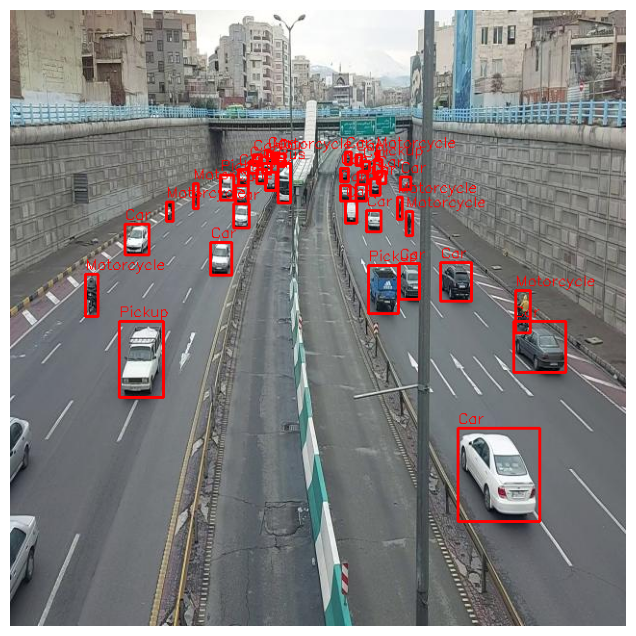

In [10]:
label_path = image_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'

class_names = {
    0: 'Bus', 
    1: 'Car', 
    2: 'Motorcycle', 
    3: 'Pickup', 
    4: 'Truck'
}

img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError('Cannot read Image')

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

if not os.path.exists(label_path):
    raise FileNotFoundError(f'Label not found: {label_path}')

with open(label_path, 'r') as f:
    for line in f:
        class_id, x, y, bw, bh = map(float, line.strip().split())

        # Convert YOLO -> pixel
        x_center = int(x * w)
        y_center = int(y * h)
        box_w = int(bw * w)
        box_h = int(bh * h)

        xmin = int(x_center - box_w / 2)
        ymin = int(y_center - box_h / 2)
        xmax = int(x_center + box_w / 2)
        ymax = int(y_center + box_h / 2)

        # Draw bbox
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
        label = class_names.get(int(class_id), str(int(class_id)))

        cv2.putText(
            img, 
            label, 
            (xmin, ymin - 5), 
            cv2.FONT_HERSHEY_SIMPLEX, 
            0.5, 
            (255, 0, 0), 
            1
        )

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.show()
plt.close()

In [9]:
dataset_path = 'dataset/vehicle_detection/vehicle-detection-image-dataset/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.yolov8'

yaml_file_path = os.path.join(dataset_path, 'data.yaml')

with open(yaml_file_path, 'r') as file:
    yaml_content = yaml.load(file, Loader=yaml.FullLoader)
    print(yaml.dump(yaml_content, default_flow_style=False))

names:
- Bus
- Car
- Motorcycle
- Pickup
- Truck
nc: 5
roboflow:
  license: Private
  project: vehicles_detection-gvrhr
  url: https://app.roboflow.com/hana-v8gbl/vehicles_detection-gvrhr/8
  version: 8
  workspace: hana-v8gbl
test: ../test/images
train: ../train/images
val: ../valid/images



In [12]:
train_images_path = os.path.join(dataset_path, 'train', 'images')
valid_images_path = os.path.join(dataset_path, 'valid', 'images')

num_train_images = 0
num_valid_images = 0

train_image_sizes = set()
valid_image_sizes = set()

for filename in os.listdir(train_images_path):
    if filename.endswith('.jpg'):
        num_train_images += 1
        image_path = os.path.join(train_images_path, filename)
        with Image.open(image_path) as img:
            train_image_sizes.add(img.size)

for filename in os.listdir(valid_images_path):
    if filename.endswith('.jpg'):
        num_valid_images += 1
        image_path = os.path.join(valid_images_path, filename)
        with Image.open(image_path) as img:
            valid_image_sizes.add(img.size)

print(f"Number of train images: {num_train_images}")
print(f"Number of valid images: {num_valid_images}")

if len(train_image_sizes) == 1:
    print(f"All train images have the same size: {train_image_sizes.pop()}")
else:
    print("Train images have varying sizes")

if len(valid_image_sizes) == 1:
    print(f"All valid images have the same size: {valid_image_sizes.pop()}")
else:
    print("Valid images have varying sizes")

Number of train images: 102
Number of valid images: 28
All train images have the same size: (640, 640)
All valid images have the same size: (640, 640)


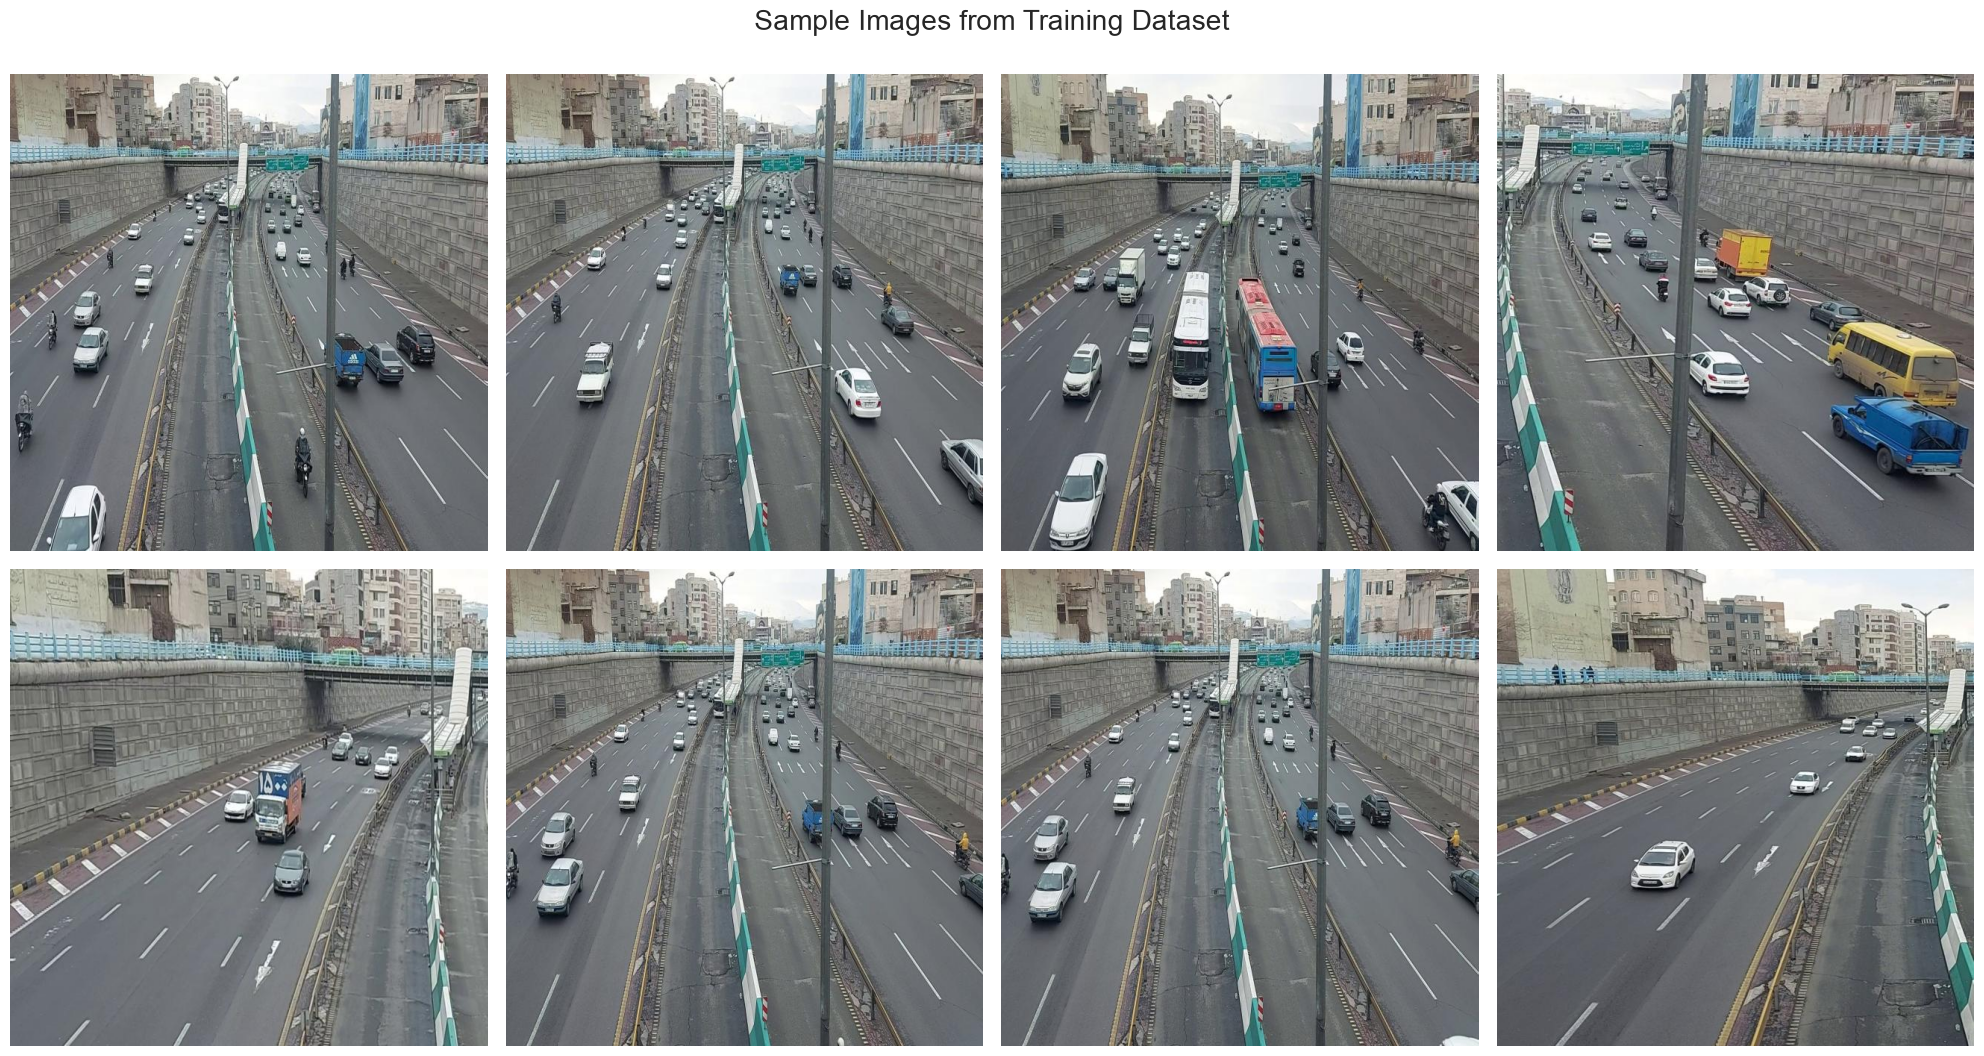

In [14]:
image_files = [file for file in os.listdir(train_images_path) if file.endswith('.jpg')]

num_images = len(image_files)
selected_images = [image_files[i] for i in range(0, num_images, num_images // 8)]

fig, axes = plt.subplots(2, 4, figsize=(20, 11))

for ax, img_file in zip(axes.ravel(), selected_images):
    img_path = os.path.join(train_images_path, img_file)
    image = Image.open(img_path)
    ax.imshow(image)
    ax.axis('off')

plt.suptitle('Sample Images from Training Dataset', fontsize=20)
plt.tight_layout()
plt.show()
plt.close()

In [16]:
current_dir = os.getcwd()
results = model.train(
    data=yaml_file_path, 
    epochs=30, 
    imgsz=640, 
    device='mps', 
    batch=32, 
    optimizer='auto', 
    lr0=0.0001, 
    lrf=0.1, 
    dropout=0.1, 
    seed=0, 
    project=os.path.join(current_dir, 'runs'), 
    name='vehicle_detection'
)

New https://pypi.org/project/ultralytics/8.4.106 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/vehicle_detection/vehicle-detection-image-dataset/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.1, mask_ratio=4, max_det=300,

In [17]:
post_training_files_path = 'runs/vehicle_detection'

!ls {post_training_files_path}

args.yaml                       train_batch0.jpg
BoxF1_curve.png                 train_batch1.jpg
BoxP_curve.png                  train_batch2.jpg
BoxPR_curve.png                 train_batch80.jpg
BoxR_curve.png                  train_batch81.jpg
confusion_matrix_normalized.png train_batch82.jpg
confusion_matrix.png            val_batch0_labels.jpg
labels.jpg                      val_batch0_pred.jpg
results.csv                     weights
results.png


In [18]:
def plot_learning_curve(df, train_loss_col, val_loss_col, title):
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=df, x='epoch', y=train_loss_col, 
                 label='Train Loss', color='#141140', linestyle='-', linewidth=2)
    sns.lineplot(data=df, x='epoch', y=val_loss_col, 
                 label='Validation Loss', color='orangered', linestyle='--', linewidth=2)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

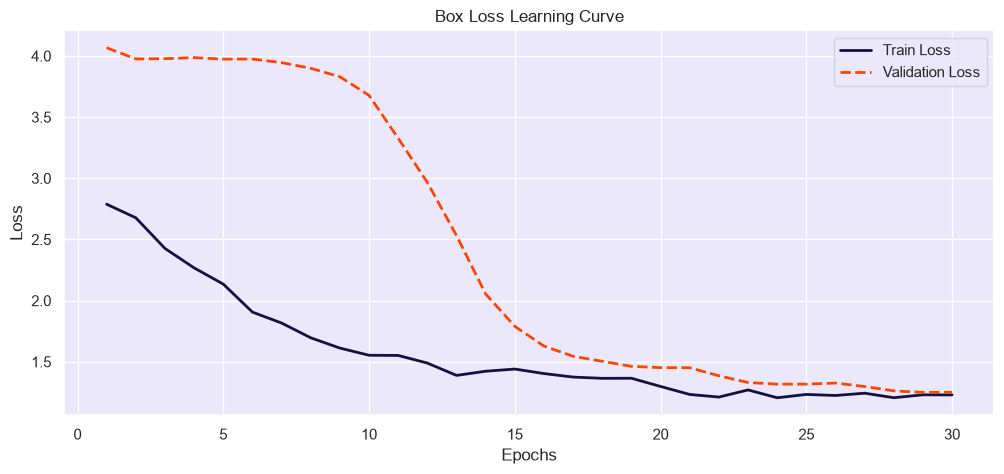

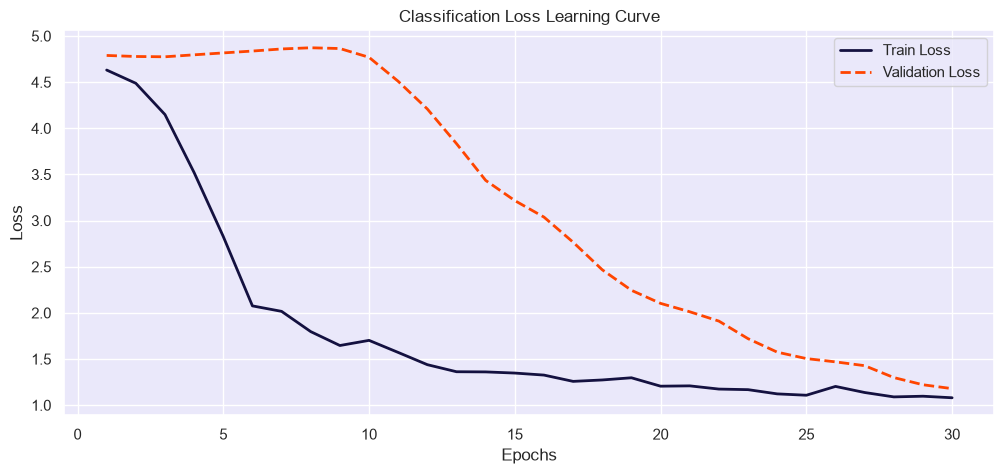

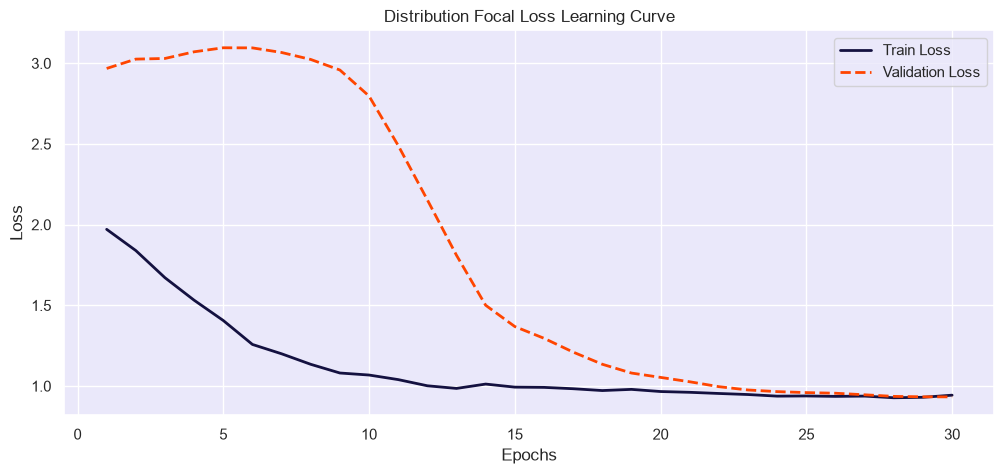

In [19]:
results_csv_path = os.path.join(post_training_files_path, 'results.csv')

df = pd.read_csv(results_csv_path)

df.columns = df.columns.str.strip()

plot_learning_curve(df, 'train/box_loss', 'val/box_loss', 'Box Loss Learning Curve')
plot_learning_curve(df, 'train/cls_loss', 'val/cls_loss', 'Classification Loss Learning Curve')
plot_learning_curve(df, 'train/dfl_loss', 'val/dfl_loss', 'Distribution Focal Loss Learning Curve')

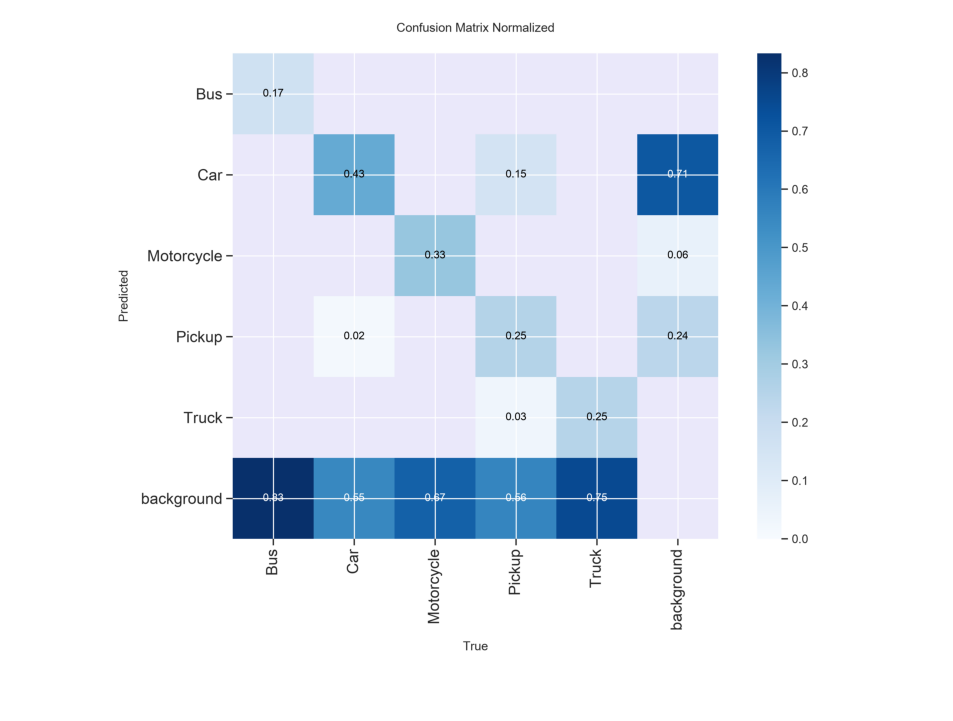

In [20]:
confusion_matrix_path = os.path.join(post_training_files_path, 'confusion_matrix_normalized.png')

cm_img = cv2.imread(confusion_matrix_path)

cm_img = cv2.cvtColor(cm_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10), dpi=120)
plt.imshow(cm_img)
plt.axis('off')
plt.show()

In [22]:
best_model_path = os.path.join(post_training_files_path, 'weights/best.pt')

best_model = YOLO(best_model_path)

metrics = best_model.val(
    split='val', 
    project=os.path.join(current_dir, 'validation'), 
    name='vehicle_detection'
)

Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 176.7±98.3 MB/s, size: 65.8 KB)
val: Scanning /Users/jeongjaehun/Github/03_object_detection/dataset/vehicle_detection/vehicle-detection-image-dataset/No_Apply_Grayscale/No_Apply_Grayscale/Vehicles_Detection.v8i.yolov8/valid/labels.cache... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28 29.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2s/it 2.4s6.1s
                   all         28        563      0.541      0.421      0.422       0.26
                   Bus          6          6       0.51      0.167      0.193       0.16
                   Car         23        398      0.722      0.633      0.701      0.448
            Motorcycle         18         92      0.807      0.413       0.55       0.27
     